In [1]:
# ==========================================
# CELL 1: Environment Setup & System Imports
# ==========================================

# 1. Install required packages
!pip install --force-reinstall "numpy==1.26.4" "pandas==2.0.3" --break-system-packages
!pip install yfinance Pillow matplotlib imageio torch torchvision --break-system-packages

# 2. System and Environment utilities
import os
import sys
import time

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
  Using cached pandas-2.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (18 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
Using cached pandas-2.0.3-cp311-cp311-macosx_11_0_arm64.whl (10.7 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.2
    Uninstalling pytz-2026.2:
      Successfully uninstalled pytz-2026.2
  Attempting uninstall: tzdata
    Fou

In [2]:
# ==============================================================================
# CELL 2: Project Architecture Imports
# ==============================================================================
import os

# Data Analysis Stack
import numpy as np
import pandas as pd
import yfinance as yf

# Deep Learning Framework
import torch
import torchvision
from torch.utils.data import TensorDataset, DataLoader

# Computer Vision & Image Processing
import imageio
from PIL import Image, ImageDraw, ImageFont

# Data Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

/Users/sivnaseth/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 1. Data Preprocessing

## 1. Upload data

In [3]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [4]:
# 1. Fetch the data
gold = yf.Ticker('GLD').history(start='2005-01-01', end='2025-12-31')
gold = gold[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Keep a snapshot of the original data so we can see what changes
original_gold = gold.copy()

# 2. Recorrect High and Low 
gold['High'] = gold[['High', 'Open', 'Close']].max(axis=1)
gold['Low'] = gold[['Low', 'Open', 'Close']].min(axis=1)

# 3. Track the changes
# Find rows where the new High is different from the old High
fixed_highs = gold[gold['High'] != original_gold['High']]
# Find rows where the new Low is different from the old Low
fixed_lows = gold[gold['Low'] != original_gold['Low']]

print(f"Total Highs corrected: {len(fixed_highs)}")
print(f"Total Lows corrected: {len(fixed_lows)}\n")

if not fixed_highs.empty or not fixed_lows.empty:
    print("Example of a corrected row (Original vs Corrected):")
    # Let's grab the first date that got fixed
    first_fixed_date = (pd.concat([fixed_highs, fixed_lows])).index[0]
    
    print("\n--- ORIGINAL ---")
    print(original_gold.loc[[first_fixed_date], ['Open', 'High', 'Low', 'Close']])
    print("\n--- CORRECTED ---")
    print(gold.loc[[first_fixed_date], ['Open', 'High', 'Low', 'Close']])
    print("\n")

# 4. View the final corrected data
print(gold)

Total Highs corrected: 0
Total Lows corrected: 0

                                 Open        High         Low       Close  \
Date                                                                        
2005-01-03 00:00:00-05:00   42.980000   43.169998   42.740002   43.020000   
2005-01-04 00:00:00-05:00   42.799999   42.910000   42.459999   42.740002   
2005-01-05 00:00:00-05:00   42.750000   42.880001   42.599998   42.669998   
2005-01-06 00:00:00-05:00   42.480000   42.560001   42.070000   42.150002   
2005-01-07 00:00:00-05:00   42.090000   42.389999   41.700001   41.840000   
...                               ...         ...         ...         ...   
2025-12-23 00:00:00-05:00  410.299988  413.760010  407.100006  413.640015   
2025-12-24 00:00:00-05:00  412.250000  412.630005  408.829987  411.929993   
2025-12-26 00:00:00-05:00  416.480011  418.450012  414.750000  416.739990   
2025-12-29 00:00:00-05:00  403.660004  403.760010  395.329987  398.600006   
2025-12-30 00:00:00-05:00 

## 2. Preprocessing

In [5]:
gold.info()
gold.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5282 entries, 2005-01-03 00:00:00-05:00 to 2025-12-30 00:00:00-05:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5282 non-null   float64
 1   High    5282 non-null   float64
 2   Low     5282 non-null   float64
 3   Close   5282 non-null   float64
 4   Volume  5282 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 247.6 KB


,Open,High,Low,Close,Volume
count,5282.000000,5282.000000,5282.000000,5282.000000,5.282000e+03
mean,136.673255,137.332253,135.955850,136.676323,9.544216e+06
std,59.370321,59.613978,59.065995,59.380642,6.726520e+06
min,41.029999,41.360001,41.020000,41.259998,3.193000e+05
25%,106.982502,107.589998,106.569998,107.115000,5.374500e+06
50%,125.174999,125.570000,124.680000,125.139999,7.937000e+06
75%,166.497501,167.125004,165.770004,166.479996,1.166142e+07
max,416.480011,418.450012,414.750000,416.739990,9.380420e+07


In [6]:
gold['Volume'] = gold['Volume'].astype(float)

In [7]:
gold.info()
gold.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5282 entries, 2005-01-03 00:00:00-05:00 to 2025-12-30 00:00:00-05:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5282 non-null   float64
 1   High    5282 non-null   float64
 2   Low     5282 non-null   float64
 3   Close   5282 non-null   float64
 4   Volume  5282 non-null   float64
dtypes: float64(5)
memory usage: 247.6 KB


,Open,High,Low,Close,Volume
count,5282.000000,5282.000000,5282.000000,5282.000000,5.282000e+03
mean,136.673255,137.332253,135.955850,136.676323,9.544216e+06
std,59.370321,59.613978,59.065995,59.380642,6.726520e+06
min,41.029999,41.360001,41.020000,41.259998,3.193000e+05
25%,106.982502,107.589998,106.569998,107.115000,5.374500e+06
50%,125.174999,125.570000,124.680000,125.139999,7.937000e+06
75%,166.497501,167.125004,165.770004,166.479996,1.166142e+07
max,416.480011,418.450012,414.750000,416.739990,9.380420e+07


In [8]:
# Convert index to datetime (if it's not already)
gold.index = pd.to_datetime(gold.index)
# Then sort the DataFrame by date (earliest to latest)
gold = gold.sort_index(ascending=True)

In [9]:
gold

,Open,High,Low,Close,Volume
Date,,,,,
2005-01-03 00:00:00-05:00,42.980000,43.169998,42.740002,43.020000,4750400.0
2005-01-04 00:00:00-05:00,42.799999,42.910000,42.459999,42.740002,3456800.0
2005-01-05 00:00:00-05:00,42.750000,42.880001,42.599998,42.669998,2033600.0
2005-01-06 00:00:00-05:00,42.480000,42.560001,42.070000,42.150002,2556400.0
2005-01-07 00:00:00-05:00,42.090000,42.389999,41.700001,41.840000,4492700.0
...,...,...,...,...,...
2025-12-23 00:00:00-05:00,410.299988,413.760010,407.100006,413.640015,13193300.0
2025-12-24 00:00:00-05:00,412.250000,412.630005,408.829987,411.929993,6718400.0
2025-12-26 00:00:00-05:00,416.480011,418.450012,414.750000,416.739990,10476200.0


In [10]:
gold.isna().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [11]:
# Compute 20-day Moving Average on the Close price
gold['MA20'] = gold['Close'].rolling(window=20).mean()
gold = gold.dropna(subset=['MA20'])

In [12]:
gold

,Open,High,Low,Close,Volume,MA20
Date,,,,,,
2005-01-31 00:00:00-05:00,42.209999,42.299999,41.959999,42.220001,1692400.0,42.445000
2005-02-01 00:00:00-05:00,42.090000,42.139999,41.950001,42.099998,1088900.0,42.399000
2005-02-02 00:00:00-05:00,42.220001,42.230000,42.020000,42.160000,956500.0,42.370000
2005-02-03 00:00:00-05:00,41.560001,41.740002,41.500000,41.680000,2446400.0,42.320500
2005-02-04 00:00:00-05:00,41.590000,41.650002,41.389999,41.470001,1819400.0,42.286500
...,...,...,...,...,...,...
2025-12-23 00:00:00-05:00,410.299988,413.760010,407.100006,413.640015,13193300.0,392.475500
2025-12-24 00:00:00-05:00,412.250000,412.630005,408.829987,411.929993,6718400.0,394.068001
2025-12-26 00:00:00-05:00,416.480011,418.450012,414.750000,416.739990,10476200.0,395.749001


In [13]:
passes = []

# 10-year training windows starting from 2005
train_starts = [2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005]
train_ends   = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
# 1-year validation immediately after trainin
val_starts   = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
val_ends     = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
# 1-year testing immediately after validatio
test_starts  = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
test_ends    = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

def slice_period(df, start_year, end_year):
    return df[(df.index.year >= start_year) & (df.index.year <= end_year)]

for i in range(len(train_starts)):
    # 1. Base Slices
    train_df = slice_period(gold, train_starts[i], train_ends[i])
    val_df   = slice_period(gold, val_starts[i],   val_ends[i])
    test_df_original = slice_period(gold, test_starts[i],  test_ends[i])
    
    # 2. STITCH ONLY VAL -> TEST
    lookback = 4+60  
    original_test_len = len(test_df_original)
    
    # Grab the last 64 days of Validation and attach to the front of Testing
    if len(val_df) >= lookback:
        test_df = pd.concat([val_df.iloc[-lookback:], test_df_original])
    else:
        test_df = test_df_original.copy()
    
    # 3. Save to passes
    passes.append({
        "pass": i+1,
        "train_years": (train_starts[i], train_ends[i]),
        "val_years":   (val_starts[i],   val_ends[i]),
        "test_years":  (test_starts[i],  test_ends[i]),
        "train_df": train_df,
        "val_df":   val_df,
        "test_df":  test_df,
        "test_orig_len": original_test_len # Storing this for the clear printout
    })

# --- VERIFICATION PRINT ---
for p in passes:
    lookback_added = len(p['test_df']) - p['test_orig_len']
    
    print(
        f"Pass {p['pass']}: "
        f"Train {p['train_years'][0]}–{p['train_years'][1]}, "
        f"Val {p['val_years'][0]}–{p['val_years'][1]}, "
        f"Test {p['test_years'][0]}–{p['test_years'][1]}, "
        f"Sizes: Train={len(p['train_df'])}, Val={len(p['val_df'])}, "
        f"Test={p['test_orig_len']} + {lookback_added}" # This gives you the "9+252" style
    )

Pass 1: Train 2005–2014, Val 2015–2015, Test 2016–2016, Sizes: Train=2498, Val=252, Test=252 + 64
Pass 2: Train 2005–2015, Val 2016–2016, Test 2017–2017, Sizes: Train=2750, Val=252, Test=251 + 64
Pass 3: Train 2005–2016, Val 2017–2017, Test 2018–2018, Sizes: Train=3002, Val=251, Test=251 + 64
Pass 4: Train 2005–2017, Val 2018–2018, Test 2019–2019, Sizes: Train=3253, Val=251, Test=252 + 64
Pass 5: Train 2005–2018, Val 2019–2019, Test 2020–2020, Sizes: Train=3504, Val=252, Test=253 + 64
Pass 6: Train 2005–2019, Val 2020–2020, Test 2021–2021, Sizes: Train=3756, Val=253, Test=252 + 64
Pass 7: Train 2005–2020, Val 2021–2021, Test 2022–2022, Sizes: Train=4009, Val=252, Test=251 + 64
Pass 8: Train 2005–2021, Val 2022–2022, Test 2023–2023, Sizes: Train=4261, Val=251, Test=250 + 64
Pass 9: Train 2005–2022, Val 2023–2023, Test 2024–2024, Sizes: Train=4512, Val=250, Test=252 + 64
Pass 10: Train 2005–2023, Val 2024–2024, Test 2025–2025, Sizes: Train=4762, Val=252, Test=249 + 64


### 2.1. Visual Branch

In [14]:
base_dir = "charts_passes"

# Step 1: Define the loading function
def load_images_from_folders(base_dir, passes):
    """
    Load images directly from PNG files
    """
    image_data = {}
    
    for k in range(1, len(passes) + 1):
        image_data[k] = {"train": [], "val": [], "test": []}
        
        for split in ["train", "val", "test"]:
            folder = os.path.join(base_dir, f"pass{k}", split)
            
            if not os.path.exists(folder):
                print(f"⚠️  Pass {k} - {split}: Folder not found")
                continue
            
            files = sorted([f for f in os.listdir(folder) if f.endswith(".png")])
            
            for fname in files:
                path = os.path.join(folder, fname)
                img = np.array(Image.open(path).convert("L"))
                image_data[k][split].append(img)
            
            print(f"✅ Pass {k} - {split}: {len(files)} images")
    
    return image_data

# Step 2: Load with caching
cache_file = "X_img_cnn_cache.npz"

if os.path.exists(cache_file):
    print("📦 Loading from cache...")
    start = time.time()
    
    data = np.load(cache_file)
    X_img_cnn = {}
    for p in range(1, len(passes)+1):
        X_img_cnn[p] = {}
        for split in ["train", "val", "test"]:
            key = f'pass{p}_{split}'
            if key in data:
                X_img_cnn[p][split] = data[key]
                print(f"✅ Pass {p} - {split}: {X_img_cnn[p][split].shape}")
    
    print(f"\n✅ Loaded from cache in {time.time()-start:.2f}s")
    
else:
    print("🔨 Building cache from PNG files...")
    start = time.time()
    
    # Load from PNGs (only once!)
    X_image_cnn = load_images_from_folders("charts_passes", passes)
    
    # Convert to CNN format
    X_img_cnn = {}
    save_dict = {}
    
    for p in range(1, len(passes)+1):
        X_img_cnn[p] = {}
        for split in ["train", "val", "test"]:
            if split not in X_image_cnn[p] or len(X_image_cnn[p][split]) == 0:
                continue
            
            imgs = X_image_cnn[p][split]
            arr = np.stack(imgs, axis=0)       # (N, 96, 180)
            arr = np.expand_dims(arr, axis=1)  # (N, 1, 96, 180)
            arr = arr.astype(np.float32) / 255.0
            
            X_img_cnn[p][split] = arr
            save_dict[f'pass{p}_{split}'] = arr
            print(f"✅ Pass {p} - {split}: {arr.shape}")
    
    # Save cache
    np.savez_compressed(cache_file, **save_dict)
    print(f"\n✅ Built and cached in {time.time()-start:.2f}s")

print("\n" + "="*60)

# Step 3: Convert to PyTorch tensors on GPU
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

X_img_tensor = {}

for p in range(1, len(passes)+1):
    X_img_tensor[p] = {}
    for split in ["train", "val", "test"]:
        if split in X_img_cnn[p]:
            X_img_tensor[p][split] = torch.from_numpy(X_img_cnn[p][split]).to(device)
            mem_mb = X_img_tensor[p][split].element_size() * X_img_tensor[p][split].nelement() / 1024**2
            print(f"✅ Pass {p} - {split} → GPU: {X_img_tensor[p][split].shape} ({mem_mb:.2f} MB)")

print("\n✅ All data ready for training!")

🔨 Building cache from PNG files...
✅ Pass 1 - train: 2434 images
✅ Pass 1 - val: 188 images
✅ Pass 1 - test: 252 images
✅ Pass 2 - train: 2686 images
✅ Pass 2 - val: 188 images
✅ Pass 2 - test: 251 images
✅ Pass 3 - train: 2938 images
✅ Pass 3 - val: 187 images
✅ Pass 3 - test: 251 images
✅ Pass 4 - train: 3189 images
✅ Pass 4 - val: 187 images
✅ Pass 4 - test: 252 images
✅ Pass 5 - train: 3440 images
✅ Pass 5 - val: 188 images
✅ Pass 5 - test: 253 images
✅ Pass 6 - train: 3692 images
✅ Pass 6 - val: 189 images
✅ Pass 6 - test: 252 images
✅ Pass 7 - train: 3945 images
✅ Pass 7 - val: 188 images
✅ Pass 7 - test: 251 images
✅ Pass 8 - train: 4197 images
✅ Pass 8 - val: 187 images
✅ Pass 8 - test: 250 images
✅ Pass 9 - train: 4448 images
✅ Pass 9 - val: 186 images
✅ Pass 9 - test: 252 images
✅ Pass 10 - train: 4698 images
✅ Pass 10 - val: 188 images
✅ Pass 10 - test: 249 images
✅ Pass 1 - train: (2434, 1, 96, 180)
✅ Pass 1 - val: (188, 1, 96, 180)
✅ Pass 1 - test: (252, 1, 96, 180)
✅ Pass

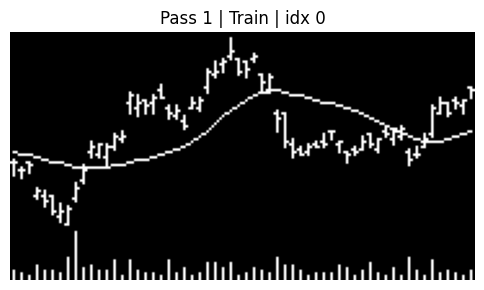

In [15]:
# Extract the first image and denormalize
img = X_img_cnn[1]["train"][0]  # Shape: (1, 96, 180)
img = img.squeeze()              # Remove channel: (96, 180)
img = (img * 255).astype(np.uint8)  # Denormalize to [0, 255]

plt.figure(figsize=(6, 10))  # Adjusted for 96x180 aspect ratio
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("Pass 1 | Train | idx 0")
plt.show()

### 2.2 Temporal Branch

In [16]:
for p in passes:

    # --- TRAIN ---
    X_train_df = p["train_df"].copy()

    # Save
    p["X_train_df"] = X_train_df

    # --- VALIDATION ---
    X_val_df = p["val_df"].copy()

    # Save
    p["X_val_df"] = X_val_df

    # --- TEST ---
    X_test_df = p["test_df"].copy()

    # Save
    p["X_test_df"] = X_test_df

In [17]:
X_train_p = {}
X_val_p = {}
X_test_p = {}

for i in range(len(passes)):   
    X_train_p[i+1] = passes[i]["X_train_df"]
    X_val_p[i+1]   = passes[i]["X_val_df"]
    X_test_p[i+1]  = passes[i]["X_test_df"]

In [18]:
window_size = 60
X_train_scaled, X_val_scaled, X_test_scaled = {}, {}, {}  # ← added back
X_train_win, X_val_win, X_test_win = {}, {}, {}

for p in range(1, len(passes) + 1):
    print(f"\n📊 PASS {p}")

    # -------- 1. Drop last 5 rows --------
    train_scaled = X_train_p[p].iloc[:-5].copy()
    val_scaled   = X_val_p[p].iloc[:-5].copy()
    test_scaled  = X_test_p[p].iloc[:-5].copy()

    # Store scaled dicts too
    X_train_scaled[p] = train_scaled
    X_val_scaled[p]   = val_scaled
    X_test_scaled[p]  = test_scaled

    # Guard check
    for name, df in zip(["Train", "Val", "Test"], [train_scaled, val_scaled, test_scaled]):
        if len(df) < window_size:
            print(f"⚠️ Warning: {name} length ({len(df)}) is smaller than window_size ({window_size})")

    # -------- 2. Make windows --------
    def make_windows(df, window_size=5):
        F = df.to_numpy(dtype=np.float32)
        N, Fdim = F.shape
        S = N - window_size + 1
        if S <= 0:
            return np.empty((0, window_size, Fdim), dtype=np.float32)
        X = np.stack([F[i:i+window_size] for i in range(S)], axis=0)
        return X

    X_train_win[p] = make_windows(train_scaled, window_size)
    X_val_win[p]   = make_windows(val_scaled,   window_size)
    X_test_win[p]  = make_windows(test_scaled,  window_size)

    print(f"  ✅ Train: scaled {train_scaled.shape}, windows {X_train_win[p].shape}")
    print(f"  ✅ Val:   scaled {val_scaled.shape},   windows {X_val_win[p].shape}")
    print(f"  ✅ Test:  scaled {test_scaled.shape},  windows {X_test_win[p].shape}")


📊 PASS 1
  ✅ Train: scaled (2493, 6), windows (2434, 60, 6)
  ✅ Val:   scaled (247, 6),   windows (188, 60, 6)
  ✅ Test:  scaled (311, 6),  windows (252, 60, 6)

📊 PASS 2
  ✅ Train: scaled (2745, 6), windows (2686, 60, 6)
  ✅ Val:   scaled (247, 6),   windows (188, 60, 6)
  ✅ Test:  scaled (310, 6),  windows (251, 60, 6)

📊 PASS 3
  ✅ Train: scaled (2997, 6), windows (2938, 60, 6)
  ✅ Val:   scaled (246, 6),   windows (187, 60, 6)
  ✅ Test:  scaled (310, 6),  windows (251, 60, 6)

📊 PASS 4
  ✅ Train: scaled (3248, 6), windows (3189, 60, 6)
  ✅ Val:   scaled (246, 6),   windows (187, 60, 6)
  ✅ Test:  scaled (311, 6),  windows (252, 60, 6)

📊 PASS 5
  ✅ Train: scaled (3499, 6), windows (3440, 60, 6)
  ✅ Val:   scaled (247, 6),   windows (188, 60, 6)
  ✅ Test:  scaled (312, 6),  windows (253, 60, 6)

📊 PASS 6
  ✅ Train: scaled (3751, 6), windows (3692, 60, 6)
  ✅ Val:   scaled (248, 6),   windows (189, 60, 6)
  ✅ Test:  scaled (311, 6),  windows (252, 60, 6)

📊 PASS 7
  ✅ Train: scaled 

### 2.3 Label

In [19]:
train_df

,Open,High,Low,Close,Volume,MA20
Date,,,,,,
2005-01-31 00:00:00-05:00,42.209999,42.299999,41.959999,42.220001,1692400.0,42.445000
2005-02-01 00:00:00-05:00,42.090000,42.139999,41.950001,42.099998,1088900.0,42.399000
2005-02-02 00:00:00-05:00,42.220001,42.230000,42.020000,42.160000,956500.0,42.370000
2005-02-03 00:00:00-05:00,41.560001,41.740002,41.500000,41.680000,2446400.0,42.320500
2005-02-04 00:00:00-05:00,41.590000,41.650002,41.389999,41.470001,1819400.0,42.286500
...,...,...,...,...,...,...
2023-12-22 00:00:00-05:00,191.600006,191.880005,190.070007,190.270004,7176300.0,187.909499
2023-12-26 00:00:00-05:00,190.970001,191.740005,190.399994,191.720001,4502700.0,188.156999
2023-12-27 00:00:00-05:00,191.770004,193.179993,191.539993,192.589996,5813300.0,188.323499


### Snippet 2: Target (Future)
This snippet creates the **prediction target** (label) for the model.

* **Concept:** Future Return (Prediction Target)
* **Direction:** Forward-looking
* **Window:** 5 Days
* **Formula:** $(Price_{+5} - Price_{Today}) / Price_{Today}$
* **NaN Handling:** Removes all NaN rows (clean dataset)

In [20]:
for p in passes:

    # --- TRAIN ---
    train_df = p["train_df"].copy()
    train_df['Return'] = (train_df['Close'].shift(-5) - train_df['Close']) / train_df['Close']
    train_df = train_df.dropna()  # Drops the last 5 rows (invalid targets)
    train_df = train_df.iloc[59:]  # <--- NEW: Drops the first 4 rows
    p["train_df"] = train_df
    p["y_train_df"] = train_df[['Return']]

    # --- VAL ---
    val_df = p["val_df"].copy()
    val_df['Return'] = (val_df['Close'].shift(-5) - val_df['Close']) / val_df['Close']
    val_df = val_df.dropna()
    val_df = val_df.iloc[59:]      # <--- NEW
    p["val_df"] = val_df
    p["y_val_df"] = val_df[['Return']]

    # --- TEST ---
    test_df = p["test_df"].copy()
    test_df['Return'] = (test_df['Close'].shift(-5) - test_df['Close']) / test_df['Close']
    test_df = test_df.dropna()
    test_df = test_df.iloc[59:]    # <--- NEW
    p["test_df"] = test_df
    p["y_test_df"] = test_df[['Return']]

In [21]:
 train_df

,Open,High,Low,Close,Volume,MA20,Return
Date,,,,,,,
2005-04-26 00:00:00-04:00,43.689999,43.700001,43.500000,43.639999,1531400.0,42.852500,-0.020165
2005-04-27 00:00:00-04:00,43.529999,43.540001,43.119999,43.200001,2762500.0,42.882000,-0.006944
2005-04-28 00:00:00-04:00,43.160000,43.270000,42.990002,43.000000,2260300.0,42.891000,-0.002093
2005-04-29 00:00:00-04:00,43.180000,43.610001,43.180000,43.349998,3736700.0,42.927500,-0.019146
2005-05-02 00:00:00-04:00,43.130001,43.169998,42.810001,42.880001,1707400.0,42.951500,-0.007696
...,...,...,...,...,...,...,...
2023-12-15 00:00:00-05:00,188.520004,188.960007,186.820007,187.000000,8324800.0,186.793999,0.017487
2023-12-18 00:00:00-05:00,187.500000,188.490005,187.240005,187.850006,5358000.0,187.002999,0.020602
2023-12-19 00:00:00-05:00,188.229996,189.720001,188.130005,189.130005,6025600.0,187.291000,0.018294


In [22]:
y_train = {}
y_val = {}
y_test = {}

for i in range(len(passes)):   # passes[0] → passes[9]
    y_train[i+1] = passes[i]["y_train_df"]
    y_val[i+1]   = passes[i]["y_val_df"]
    y_test[i+1]  = passes[i]["y_test_df"]

In [23]:
# Convert return to binary labels for all passes
for p in range(1, len(passes)+1):

    # TRAIN
    df_train = y_train[p].copy()
    df_train["Label"] = (df_train["Return"] > 0).astype(int)
    y_train[p] = df_train[["Label"]]

    # VAL
    df_val = y_val[p].copy()
    df_val["Label"] = (df_val["Return"] > 0).astype(int)
    y_val[p] = df_val[["Label"]]

    # TEST
    df_test = y_test[p].copy()
    df_test["Label"] = (df_test["Return"] > 0).astype(int)
    y_test[p] = df_test[["Label"]]

In [24]:
y_train[1]

,Label
Date,
2005-04-26 00:00:00-04:00,0
2005-04-27 00:00:00-04:00,0
2005-04-28 00:00:00-04:00,0
2005-04-29 00:00:00-04:00,0
2005-05-02 00:00:00-04:00,0
...,...
2014-12-17 00:00:00-05:00,0
2014-12-18 00:00:00-05:00,0
2014-12-19 00:00:00-05:00,0


In [25]:
y_train[1].tail(12)

,Label
Date,
2014-12-08 00:00:00-05:00,0
2014-12-09 00:00:00-05:00,0
2014-12-10 00:00:00-05:00,0
2014-12-11 00:00:00-05:00,0
2014-12-12 00:00:00-05:00,0
2014-12-15 00:00:00-05:00,0
2014-12-16 00:00:00-05:00,0
2014-12-17 00:00:00-05:00,0
2014-12-18 00:00:00-05:00,0


In [26]:
last_window_dates = []

for p in range(1, len(passes)+1):

    # ---- TRAIN ----
    df_train = X_train_scaled[p]
    last_date_train = df_train.index[-1]   # last window ends at last row

    # ---- VAL ----
    df_val = X_val_scaled[p]
    last_date_val = df_val.index[-1]

    # ---- TEST ----
    df_test = X_test_scaled[p]
    last_date_test = df_test.index[-1]

    last_window_dates.append({
        "Pass": p,
        "Train_last_window_date": last_date_train,
        "Val_last_window_date": last_date_val,
        "Test_last_window_date": last_date_test
    })

last_window_df = pd.DataFrame(last_window_dates).set_index("Pass")
print(last_window_df)

        Train_last_window_date      Val_last_window_date  \
Pass                                                       
1    2014-12-23 00:00:00-05:00 2015-12-23 00:00:00-05:00   
2    2015-12-23 00:00:00-05:00 2016-12-22 00:00:00-05:00   
3    2016-12-22 00:00:00-05:00 2017-12-21 00:00:00-05:00   
4    2017-12-21 00:00:00-05:00 2018-12-21 00:00:00-05:00   
5    2018-12-21 00:00:00-05:00 2019-12-23 00:00:00-05:00   
6    2019-12-23 00:00:00-05:00 2020-12-23 00:00:00-05:00   
7    2020-12-23 00:00:00-05:00 2021-12-23 00:00:00-05:00   
8    2021-12-23 00:00:00-05:00 2022-12-22 00:00:00-05:00   
9    2022-12-22 00:00:00-05:00 2023-12-21 00:00:00-05:00   
10   2023-12-21 00:00:00-05:00 2024-12-23 00:00:00-05:00   

         Test_last_window_date  
Pass                            
1    2016-12-22 00:00:00-05:00  
2    2017-12-21 00:00:00-05:00  
3    2018-12-21 00:00:00-05:00  
4    2019-12-23 00:00:00-05:00  
5    2020-12-23 00:00:00-05:00  
6    2021-12-23 00:00:00-05:00  
7    2022-12-22

In [27]:
summary_labels = []

for p in range(1, len(passes)+1):

    # TRAIN
    train_counts = y_train[p]["Label"].value_counts().to_dict()
    train_0 = train_counts.get(0, 0)
    train_1 = train_counts.get(1, 0)

    # VAL
    val_counts = y_val[p]["Label"].value_counts().to_dict()
    val_0 = val_counts.get(0, 0)
    val_1 = val_counts.get(1, 0)

    # TEST
    test_counts = y_test[p]["Label"].value_counts().to_dict()
    test_0 = test_counts.get(0, 0)
    test_1 = test_counts.get(1, 0)

    summary_labels.append({
        "Pass": p,
        "Train_0": train_0, "Train_1": train_1,
        "Val_0": val_0,     "Val_1": val_1,
        "Test_0": test_0,   "Test_1": test_1,
    })

summary_labels_df = pd.DataFrame(summary_labels).set_index("Pass")
print(summary_labels_df)

      Train_0  Train_1  Val_0  Val_1  Test_0  Test_1
Pass                                                
1        1062     1372    112     76     123     129
2        1206     1480    104     84     111     140
3        1329     1609     91     96     132     119
4        1440     1749    100     87      98     154
5        1572     1868     72    116      98     155
6        1670     2022     75    114     111     141
7        1768     2177     73    115     128     123
8        1879     2318    106     81     125     125
9        2007     2441     95     91     102     150
10       2132     2566     79    109      73     176


In [28]:
summary_y = []

for p in range(1, len(passes)+1):
    n_train = len(y_train[p])
    n_val   = len(y_val[p])
    n_test  = len(y_test[p])
    total   = n_train + n_val + n_test

    summary_y.append({
        "Pass":  p,
        "Train": n_train,
        "Val":   n_val,
        "Test":  n_test,
        "Total": total
    })

summary_y_df = pd.DataFrame(summary_y).set_index("Pass")
print(summary_y_df)

      Train  Val  Test  Total
Pass                         
1      2434  188   252   2874
2      2686  188   251   3125
3      2938  187   251   3376
4      3189  187   252   3628
5      3440  188   253   3881
6      3692  189   252   4133
7      3945  188   251   4384
8      4197  187   250   4634
9      4448  186   252   4886
10     4698  188   249   5135


In [29]:
summary_y = []

for p in range(1, len(passes)+1):
    n_train = len(y_train[p])
    n_val   = len(y_val[p])
    n_test  = len(y_test[p])
    
    # last dates
    last_train = y_train[p].index[-1]
    last_val   = y_val[p].index[-1]
    last_test  = y_test[p].index[-1]

    summary_y.append({
        "Pass":  p,
        "Train": n_train,
        "Val":   n_val,
        "Test":  n_test,
        "Total": n_train + n_val + n_test,
        "Train_last_date": last_train,
        "Val_last_date":   last_val,
        "Test_last_date":  last_test
    })

summary_y_df = pd.DataFrame(summary_y).set_index("Pass")
summary_y_df

,Train,Val,Test,Total,Train_last_date,Val_last_date,Test_last_date
Pass,,,,,,,
1,2434,188,252,2874,2014-12-23 00:00:00-05:00,2015-12-23 00:00:00-05:00,2016-12-22 00:00:00-05:00
2,2686,188,251,3125,2015-12-23 00:00:00-05:00,2016-12-22 00:00:00-05:00,2017-12-21 00:00:00-05:00
3,2938,187,251,3376,2016-12-22 00:00:00-05:00,2017-12-21 00:00:00-05:00,2018-12-21 00:00:00-05:00
4,3189,187,252,3628,2017-12-21 00:00:00-05:00,2018-12-21 00:00:00-05:00,2019-12-23 00:00:00-05:00
5,3440,188,253,3881,2018-12-21 00:00:00-05:00,2019-12-23 00:00:00-05:00,2020-12-23 00:00:00-05:00
6,3692,189,252,4133,2019-12-23 00:00:00-05:00,2020-12-23 00:00:00-05:00,2021-12-23 00:00:00-05:00
7,3945,188,251,4384,2020-12-23 00:00:00-05:00,2021-12-23 00:00:00-05:00,2022-12-22 00:00:00-05:00
8,4197,187,250,4634,2021-12-23 00:00:00-05:00,2022-12-22 00:00:00-05:00,2023-12-21 00:00:00-05:00
9,4448,186,252,4886,2022-12-22 00:00:00-05:00,2023-12-21 00:00:00-05:00,2024-12-23 00:00:00-05:00


In [30]:
rows = []

for p in range(1, len(passes)+1):
    # ---- TRAIN ----
    rows.append({
        "Pass": p,
        "Split": "train",
        "Xwin_shape": X_train_win[p].shape,
        "Ximg_shape": X_img_cnn[p]["train"].shape,  # Already has full shape
        "Y_shape": y_train[p].shape,
        "Match": (
            X_train_win[p].shape[0] ==
            X_img_cnn[p]["train"].shape[0] ==
            y_train[p].shape[0]
        )
    })
    
    # ---- VAL ----
    rows.append({
        "Pass": p,
        "Split": "val",
        "Xwin_shape": X_val_win[p].shape,
        "Ximg_shape": X_img_cnn[p]["val"].shape,
        "Y_shape": y_val[p].shape,
        "Match": (
            X_val_win[p].shape[0] ==
            X_img_cnn[p]["val"].shape[0] ==
            y_val[p].shape[0]
        )
    })
    
    # ---- TEST ----
    rows.append({
        "Pass": p,
        "Split": "test",
        "Xwin_shape": X_test_win[p].shape,
        "Ximg_shape": X_img_cnn[p]["test"].shape,
        "Y_shape": y_test[p].shape,
        "Match": (
            X_test_win[p].shape[0] ==
            X_img_cnn[p]["test"].shape[0] ==
            y_test[p].shape[0]
        )
    })

compare_df = pd.DataFrame(rows).set_index(["Pass", "Split"])
print(compare_df)

               Xwin_shape          Ximg_shape    Y_shape  Match
Pass Split                                                     
1    train  (2434, 60, 6)  (2434, 1, 96, 180)  (2434, 1)   True
     val     (188, 60, 6)   (188, 1, 96, 180)   (188, 1)   True
     test    (252, 60, 6)   (252, 1, 96, 180)   (252, 1)   True
2    train  (2686, 60, 6)  (2686, 1, 96, 180)  (2686, 1)   True
     val     (188, 60, 6)   (188, 1, 96, 180)   (188, 1)   True
     test    (251, 60, 6)   (251, 1, 96, 180)   (251, 1)   True
3    train  (2938, 60, 6)  (2938, 1, 96, 180)  (2938, 1)   True
     val     (187, 60, 6)   (187, 1, 96, 180)   (187, 1)   True
     test    (251, 60, 6)   (251, 1, 96, 180)   (251, 1)   True
4    train  (3189, 60, 6)  (3189, 1, 96, 180)  (3189, 1)   True
     val     (187, 60, 6)   (187, 1, 96, 180)   (187, 1)   True
     test    (252, 60, 6)   (252, 1, 96, 180)   (252, 1)   True
5    train  (3440, 60, 6)  (3440, 1, 96, 180)  (3440, 1)   True
     val     (188, 60, 6)   (188, 1, 96,

# 2. Visual Branch and Temporal Branch

## 1. CNN

In [31]:
X_img_tensor = {}

for p in range(1, len(passes)+1):
    X_img_tensor[p] = {}
    for split in ["train", "val", "test"]:
        # Check if split exists in X_img_cnn
        if split not in X_img_cnn[p]:
            continue
        
        # Convert to PyTorch tensor and move to GPU
        arr = X_img_cnn[p][split]
        X_img_tensor[p][split] = torch.from_numpy(arr).to(device)
        print(f"✅ Pass {p} - {split} → GPU: {X_img_tensor[p][split].shape}")

print(f"\n✅ All data loaded on {device}")

✅ Pass 1 - train → GPU: torch.Size([2434, 1, 96, 180])
✅ Pass 1 - val → GPU: torch.Size([188, 1, 96, 180])
✅ Pass 1 - test → GPU: torch.Size([252, 1, 96, 180])
✅ Pass 2 - train → GPU: torch.Size([2686, 1, 96, 180])
✅ Pass 2 - val → GPU: torch.Size([188, 1, 96, 180])
✅ Pass 2 - test → GPU: torch.Size([251, 1, 96, 180])
✅ Pass 3 - train → GPU: torch.Size([2938, 1, 96, 180])
✅ Pass 3 - val → GPU: torch.Size([187, 1, 96, 180])
✅ Pass 3 - test → GPU: torch.Size([251, 1, 96, 180])
✅ Pass 4 - train → GPU: torch.Size([3189, 1, 96, 180])
✅ Pass 4 - val → GPU: torch.Size([187, 1, 96, 180])
✅ Pass 4 - test → GPU: torch.Size([252, 1, 96, 180])
✅ Pass 5 - train → GPU: torch.Size([3440, 1, 96, 180])
✅ Pass 5 - val → GPU: torch.Size([188, 1, 96, 180])
✅ Pass 5 - test → GPU: torch.Size([253, 1, 96, 180])
✅ Pass 6 - train → GPU: torch.Size([3692, 1, 96, 180])
✅ Pass 6 - val → GPU: torch.Size([189, 1, 96, 180])
✅ Pass 6 - test → GPU: torch.Size([252, 1, 96, 180])
✅ Pass 7 - train → GPU: torch.Size([3945

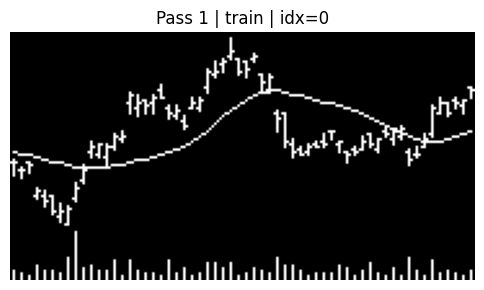

In [32]:
# Pick any pass + split + index
p = 1
split = "train"
idx = 0

# Extract and prepare image
img_np = X_img_cnn[p][split][idx]      # Shape: (1, 96, 180), values: [0, 1]
img_np = img_np.squeeze()               # Shape: (96, 180)
img_np = (img_np * 255).astype(np.uint8)  # Denormalize to [0, 255]

# Convert to PIL (optional - matplotlib can handle numpy directly)
img_pil = Image.fromarray(img_np)

plt.figure(figsize=(6, 10))
plt.imshow(img_pil, cmap="gray", vmin=0, vmax=255)
plt.title(f"Pass {p} | {split} | idx={idx}")
plt.axis("off")
plt.show()

### 1.2. Label Matching

In [33]:
def _to_numpy_imgs(X):
    """Convert torch/numpy/list to numpy, squeeze channel dimension"""
    if "torch" in str(type(X)):
        X = X.detach().cpu().numpy()
    X = np.asarray(X)
    # NCHW -> NHW
    if X.ndim == 4 and X.shape[1] == 1:
        X = X[:, 0, :, :]          # (N,1,H,W) -> (N,H,W)
    elif X.ndim == 4 and X.shape[-1] == 1:
        X = X[..., 0]              # (N,H,W,1) -> (N,H,W)
    return X

def _to_numpy_labels(y):
    """Convert labels to numpy and flatten"""
    if "torch" in str(type(y)):
        y = y.detach().cpu().numpy()
    y = np.asarray(y).astype(float)
    # Ensure 1D array
    if y.ndim > 1:
        y = y.flatten()
    return y

def preview_t_t5(X, y, H=96, W=180, n_show=2, set_name="Set", seed=0):
    """
    Visualize chart evolution from time t to t+5
    
    Args:
        X: Images (N,H,W) or (N,1,H,W) numpy/torch
        y: Labels (N,) numpy/torch  
        H, W: Image dimensions (default 96x180)
        n_show: Number of examples to show
        set_name: Display name for the dataset
        seed: Random seed for sample selection
    """
    X = _to_numpy_imgs(X)
    y = _to_numpy_labels(y)
    
    assert X.ndim == 3 and X.shape[1] == H and X.shape[2] == W, \
        f"Expected X shape (N,{H},{W}); got {X.shape}"
    assert len(X) == len(y), f"Length mismatch: X={len(X)} vs y={len(y)}"
    
    N = len(X)
    if N < 6:
        print(f"[{set_name}] Not enough samples to show t+5 (need >= 6, got {N}).")
        return
    
    valid = np.arange(0, N - 5)   # Ensure t+5 exists
    rng = np.random.default_rng(seed)
    k = min(n_show, len(valid))
    starts = rng.choice(valid, size=k, replace=False)
    
    fig, axes = plt.subplots(k, 2, figsize=(10, 5 * k))
    if k == 1:
        axes = np.array([axes])
    
    for r, i in enumerate(starts):
        t, t5 = i, i + 5
        
        # Extract scalar values from labels
        y_t = float(y[t])
        y_t5 = float(y[t5])
        
        # -------- t (left): red on last 3 columns --------
        ax = axes[r, 0]
        # Denormalize if needed (values in [0,1])
        img_t = X[t] * 255 if X[t].max() <= 1.0 else X[t]
        ax.imshow(img_t, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        ax.axis("off")
        
        if W >= 3:
            ax.add_patch(Rectangle((W - 3 - 0.5, -0.5), 3.0, H,
                                   facecolor='red', alpha=0.30, edgecolor='none'))
        ax.set_title(f"{set_name} • t (idx={t}) • y={y_t:.2f}", fontsize=11)
        
        # -------- t+5 (right): red on old columns, blue on new --------
        ax = axes[r, 1]
        img_t5 = X[t5] * 255 if X[t5].max() <= 1.0 else X[t5]
        ax.imshow(img_t5, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        ax.axis("off")
        
        # Red overlay on "old" region
        if W >= 18:
            ax.add_patch(Rectangle((W - 18 - 0.5, -0.5), 3.0, H,
                                   facecolor='red', alpha=0.30, edgecolor='none'))
        # Blue overlay on "new" region
        if W >= 15:
            ax.add_patch(Rectangle((W - 15 - 0.5, -0.5), 3.0, H,
                                   facecolor='blue', alpha=0.30, edgecolor='none'))
        
        ax.set_title(f"{set_name} • t+5 (idx={t5}) • y={y_t5:.2f}", fontsize=11)
    
    plt.tight_layout()
    plt.show()

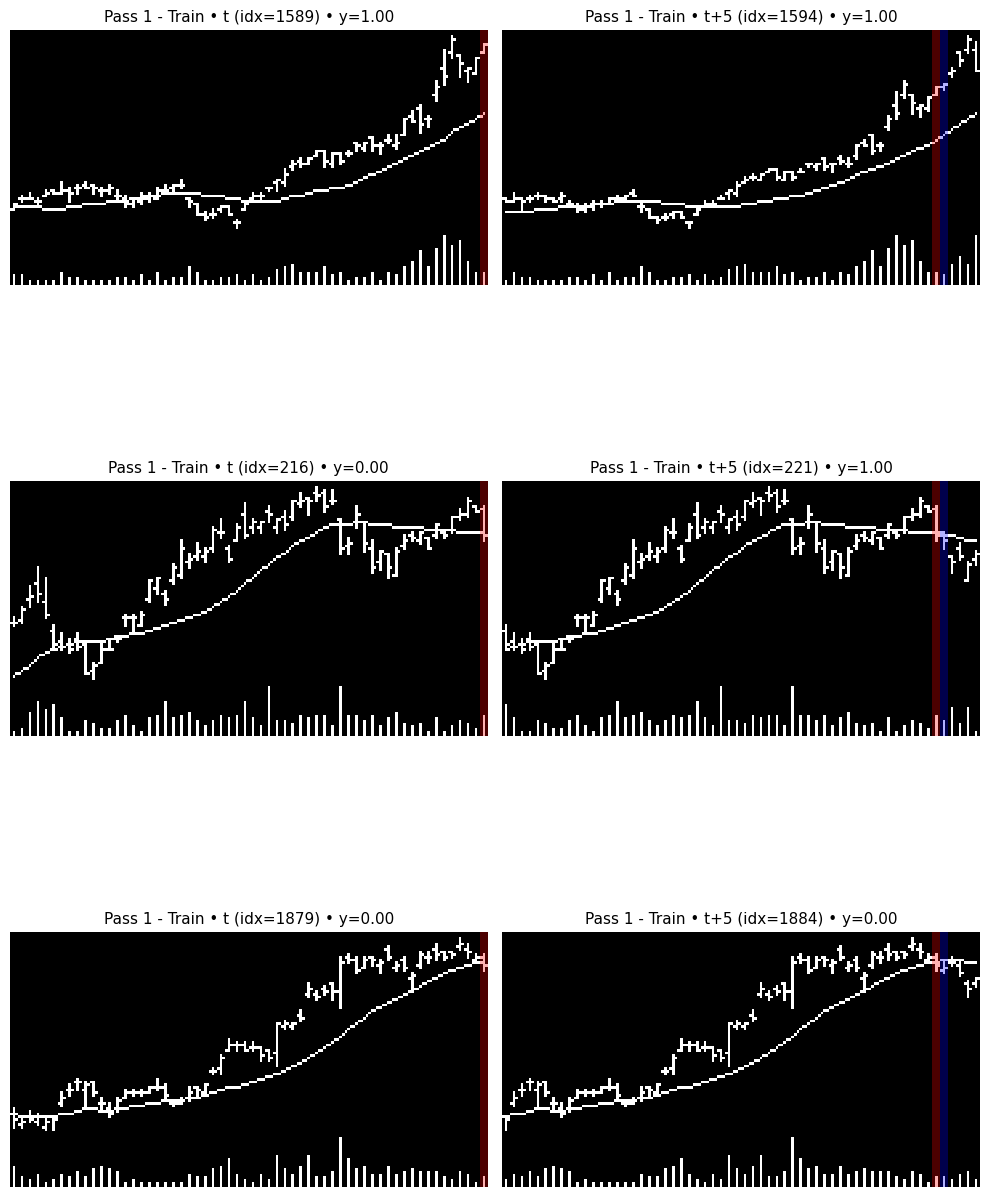

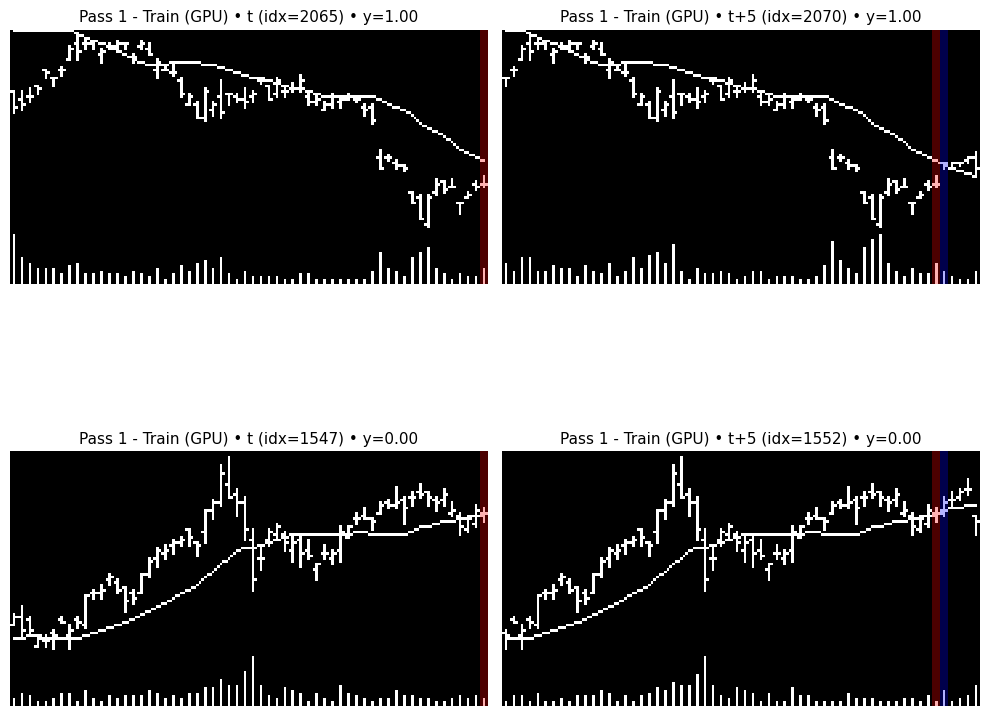

In [34]:
# Example 1: Visualize from X_img_cnn (normalized numpy arrays)
preview_t_t5(
    X=X_img_cnn[1]["train"],  # (N, 1, 96, 180) normalized [0,1]
    y=y_train[1],              # Your labels
    H=96, 
    W=180, 
    n_show=3,
    set_name="Pass 1 - Train",
    seed=42
)

# Example 2: Visualize from PyTorch tensors
preview_t_t5(
    X=X_img_tensor[1]["train"],  # PyTorch tensor on GPU
    y=y_train[1],
    H=96, 
    W=180, 
    n_show=2,
    set_name="Pass 1 - Train (GPU)",
    seed=0
)

# Example 3: X_img_cnn already has the right format, no need to reconstruct
# Just use it directly as in Example 1

In [35]:
# Create reference (not a copy - same memory)
X_img_cnn_scaled = X_img_cnn

# Verify it's already normalized
sample = X_img_cnn_scaled[1]["train"][0]
print(f"✅ Data range: [{sample.min():.3f}, {sample.max():.3f}]")
print(f"   Already normalized to [0, 1]: {sample.min() >= 0 and sample.max() <= 1}")

✅ Data range: [0.000, 1.000]
   Already normalized to [0, 1]: True


## 2. ViT

In [36]:
X_img_vit = X_img_cnn

print("✅ X_img_vit created (same as X_img_cnn)")
print(f"   Example shape: {X_img_vit[1]['train'].shape}")
print(f"   Data type: {X_img_vit[1]['train'].dtype}")
print(f"   Value range: [{X_img_vit[1]['train'].min():.3f}, {X_img_vit[1]['train'].max():.3f}]")

✅ X_img_vit created (same as X_img_cnn)
   Example shape: (2434, 1, 96, 180)
   Data type: float32
   Value range: [0.000, 1.000]


patches shape: (8, 20, 12, 9, 1)
patch size   : (12, 9)


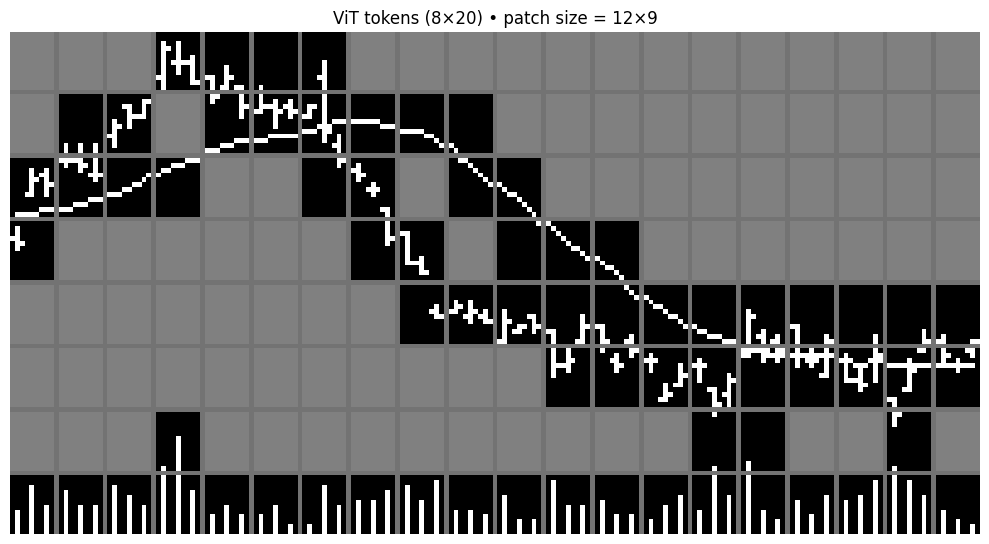

In [37]:
def _to_numpy_f32(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return np.asarray(x, dtype=np.float32)

def _to_hwc(x):
    """(H,W) or (C,H,W) -> (H,W,C)."""
    if x.ndim == 2:
        return x[..., None]              # (H,W) -> (H,W,1)
    if x.ndim == 3 and x.shape[0] in (1, 3):
        return np.moveaxis(x, 0, -1)     # (C,H,W) -> (H,W,C)
    return x                              # already (H,W,C)

def extract_patches_hwc(img_hwc, rows, cols):
    H, W, C = img_hwc.shape
    ph = H // rows
    pw = W // cols
    patches = img_hwc.reshape(rows, ph, cols, pw, C).swapaxes(1, 2)
    return patches, (ph, pw)

def montage_with_gaps_raw(patches, gap=8, bg=128.0):
    """
    patches: (R, C, ph, pw, Ch)
    Replace patches that are fully black with solid gray (128).
    """
    R, C, ph, pw, Ch = patches.shape
    H = R*ph + (R-1)*gap
    W = C*pw + (C-1)*gap
    canvas = np.full((H, W, Ch), bg, dtype=np.float32)
    
    for r in range(R):
        for c in range(C):
            y = r*(ph + gap)
            x = c*(pw + gap)
            patch = patches[r, c]
            
            # ⭐ Detect fully black patch
            if patch.max() == 0:
                patch = np.full_like(patch, 128, dtype=np.float32)
            
            canvas[y:y+ph, x:x+pw, :] = patch
    
    return canvas

def show_vit_tokens_12x9(img, rows=8, cols=20, gap=1):
    """
    Visualize ViT tokens as a grid with gaps
    img: (1, 96, 180) or (96, 180) - values in [0, 1]
    """
    img = _to_numpy_f32(img)
    
    # Denormalize to [0, 255] for visualization
    if img.max() <= 1.0:
        img = img * 255.0
    
    img = _to_hwc(img)
    patches, (ph, pw) = extract_patches_hwc(img, rows, cols)
    
    print(f"patches shape: {patches.shape}")
    print(f"patch size   : ({ph}, {pw})")
    
    mosaic = montage_with_gaps_raw(patches, gap=gap, bg=115.0)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(mosaic.squeeze(), cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
    plt.title(f"ViT tokens ({rows}×{cols}) • patch size = {ph}×{pw}")
    plt.tight_layout()
    plt.show()
    
    return patches, mosaic

# Usage
X_img_vit = X_img_cnn  # Already in correct format

p = 1
split = "test"
idx = 0

img = X_img_vit[p][split][idx]  # Shape: (1, 96, 180), values: [0, 1]
patches, mosaic = show_vit_tokens_12x9(img, rows=8, cols=20, gap=1)

In [38]:
X_img_vit_scaled = X_img_vit

/var/folders/7c/6hr3p4x57nxgrldpc2p8y6gc0000gn/T/ipykernel_23904/2721142528.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(img_u8, mode="L")


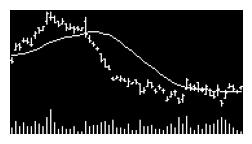

In [39]:
# Pick one image
img = X_img_vit_scaled[1]["test"][0]   # (32, 15, 1)

# Convert
img2d = img.squeeze()                   # (32, 15)
img_u8 = (img2d * 255).astype(np.uint8)
pil_img = Image.fromarray(img_u8, mode="L")

# Display in notebook
plt.figure(figsize=(3, 6))
plt.imshow(pil_img, cmap="gray")
plt.axis("off")
plt.show()

In [40]:
def show_vit_tokens_12x9(img, rows=8, cols=20, gap=1, save_svg=None):
    img = _to_numpy_f32(img)
    img = _to_hwc(img)
    patches, (ph, pw) = extract_patches_hwc(img, rows, cols)
    print("patches shape:", patches.shape)
    print("patch size   :", (ph, pw))
    mosaic = montage_with_gaps_raw(patches, gap=gap, bg=115.0)

    fig, ax = plt.subplots(figsize=(6, 10))
    ax.imshow(mosaic.squeeze(), cmap="gray", vmin=0, vmax=255)
    ax.axis("off")
    ax.set_title("ViT tokens (8×20) • patch size = 12×9")

    # ⭐ Save as SVG
    if save_svg is not None:
        fig.savefig(save_svg, format="svg", bbox_inches="tight", pad_inches=0.1)
        print(f"Saved SVG → {save_svg}")

    plt.show()
    return patches, mosaic

## 3. Temporal

In [42]:
# X_seq_lstm[p][split] → torch.Size([N, 5, F])
X_seq = {}

for p in range(1, len(passes)+1):
    X_seq[p] = {}

    # ---- TRAIN ----
    X_seq[p]["train"] = torch.from_numpy(
        X_train_win[p].astype(np.float32)
    )   # (N_train, 5, F)

    # ---- VAL ----
    X_seq[p]["val"] = torch.from_numpy(
        X_val_win[p].astype(np.float32)
    )   # (N_val, 5, F)

    # ---- TEST ----
    X_seq[p]["test"] = torch.from_numpy(
        X_test_win[p].astype(np.float32)
    )   # (N_test, 5, F)

In [43]:
# Pretty display of all LSTM shapes
print("📌 LSTM Tensor Shapes (batch, seq_len, features)\n")

for p in range(1, len(passes)+1):
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"📦 PASS {p}")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

    tr = X_seq[p]["train"].shape
    va = X_seq[p]["val"].shape
    te = X_seq[p]["test"].shape

    print(f"  🟢 Train : {tr}")
    print(f"  🟠 Val   : {va}")
    print(f"  🔵 Test  : {te}")
    print()

📌 LSTM Tensor Shapes (batch, seq_len, features)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📦 PASS 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟢 Train : torch.Size([2434, 60, 6])
  🟠 Val   : torch.Size([188, 60, 6])
  🔵 Test  : torch.Size([252, 60, 6])

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📦 PASS 2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟢 Train : torch.Size([2686, 60, 6])
  🟠 Val   : torch.Size([188, 60, 6])
  🔵 Test  : torch.Size([251, 60, 6])

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📦 PASS 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟢 Train : torch.Size([2938, 60, 6])
  🟠 Val   : torch.Size([187, 60, 6])
  🔵 Test  : torch.Size([251, 60, 6])

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📦 PASS 4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟢 Train : torch.Size([3189, 60, 6])
  🟠 Val   : torch.Size([187, 60, 6])
  🔵 Test  : torch.Size([252, 60, 6])

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📦 PASS 5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟢 Train : torch.Size([3440, 60, 6])
  🟠 Val   : torch.Size([188, 60, 6])
  🔵 Test  : torch.Size([253, 60, 6])

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📦 PASS 6
━━━━━━━━━━━━━

## 4. Label

In [44]:
# y_torch[p]["train" | "val" | "test"] -> tensor (N,)
y_torch = {}

for p in range(1, len(passes)+1):
    y_torch[p] = {}

    # assume label column is named "Label"
    y_torch[p]["train"] = torch.from_numpy(
        y_train[p]["Label"].to_numpy(dtype=np.float32)
    )  # for BCEWithLogitsLoss

    y_torch[p]["val"] = torch.from_numpy(
        y_val[p]["Label"].to_numpy(dtype=np.float32)
    )

    y_torch[p]["test"] = torch.from_numpy(
        y_test[p]["Label"].to_numpy(dtype=np.float32)
    )

In [45]:
print("📌 Label tensor shapes\n")
for p in range(1, len(passes)+1):
    print(f"PASS {p}")
    for split in ["train", "val", "test"]:
        print(f"  {split:5s}: {y_torch[p][split].shape},  dtype={y_torch[p][split].dtype}")
    print()

📌 Label tensor shapes

PASS 1
  train: torch.Size([2434]),  dtype=torch.float32
  val  : torch.Size([188]),  dtype=torch.float32
  test : torch.Size([252]),  dtype=torch.float32

PASS 2
  train: torch.Size([2686]),  dtype=torch.float32
  val  : torch.Size([188]),  dtype=torch.float32
  test : torch.Size([251]),  dtype=torch.float32

PASS 3
  train: torch.Size([2938]),  dtype=torch.float32
  val  : torch.Size([187]),  dtype=torch.float32
  test : torch.Size([251]),  dtype=torch.float32

PASS 4
  train: torch.Size([3189]),  dtype=torch.float32
  val  : torch.Size([187]),  dtype=torch.float32
  test : torch.Size([252]),  dtype=torch.float32

PASS 5
  train: torch.Size([3440]),  dtype=torch.float32
  val  : torch.Size([188]),  dtype=torch.float32
  test : torch.Size([253]),  dtype=torch.float32

PASS 6
  train: torch.Size([3692]),  dtype=torch.float32
  val  : torch.Size([189]),  dtype=torch.float32
  test : torch.Size([252]),  dtype=torch.float32

PASS 7
  train: torch.Size([3945]),  dtyp

## 5. Summary

In [46]:
rows = []

for p in range(1, len(passes)+1):
    for split in ["train", "val", "test"]:
        # Safely get shapes (in case something is missing)
        cnn_shape   = getattr(X_img_cnn[p][split], "shape", None)
        vit_shape   = getattr(X_img_vit[p][split], "shape", None)
        seq_shape  = getattr(X_seq[p][split], "shape", None)
        y_shape     = getattr(y_torch[p][split], "shape", None)

        rows.append({
            "Pass": p,
            "Split": split,
            "CNN":   cnn_shape,
            "ViT":   vit_shape,
            "Seq":  seq_shape,
            "Label": y_shape,
        })

shapes_df = pd.DataFrame(rows).set_index(["Pass", "Split"])
print(shapes_df)

                           CNN                 ViT            Seq    Label
Pass Split                                                                
1    train  (2434, 1, 96, 180)  (2434, 1, 96, 180)  (2434, 60, 6)  (2434,)
     val     (188, 1, 96, 180)   (188, 1, 96, 180)   (188, 60, 6)   (188,)
     test    (252, 1, 96, 180)   (252, 1, 96, 180)   (252, 60, 6)   (252,)
2    train  (2686, 1, 96, 180)  (2686, 1, 96, 180)  (2686, 60, 6)  (2686,)
     val     (188, 1, 96, 180)   (188, 1, 96, 180)   (188, 60, 6)   (188,)
     test    (251, 1, 96, 180)   (251, 1, 96, 180)   (251, 60, 6)   (251,)
3    train  (2938, 1, 96, 180)  (2938, 1, 96, 180)  (2938, 60, 6)  (2938,)
     val     (187, 1, 96, 180)   (187, 1, 96, 180)   (187, 60, 6)   (187,)
     test    (251, 1, 96, 180)   (251, 1, 96, 180)   (251, 60, 6)   (251,)
4    train  (3189, 1, 96, 180)  (3189, 1, 96, 180)  (3189, 60, 6)  (3189,)
     val     (187, 1, 96, 180)   (187, 1, 96, 180)   (187, 60, 6)   (187,)
     test    (252, 1, 96,

# 3. Data loader

In [47]:
# ============================================================
# 1. UNIVERSAL HELPER FUNCTION
# ============================================================
def create_loader(*inputs, bs=32, shuffle=False, drop_last=False, seed=42):
    """
    Generic loader builder.
    Args:
        *inputs: Variable number of arrays (e.g., X_cnn, y) or (X_vit, X_lstm, y)
    """
    tensors = []
    for x in inputs:
        t = torch.as_tensor(x, dtype=torch.float32)
        tensors.append(t)

    dataset = TensorDataset(*tensors)

    if shuffle:
        torch.manual_seed(seed)

    return DataLoader(dataset, batch_size=bs, shuffle=shuffle, drop_last=drop_last)

def get_data(p, split, keys):
    """
    Helper to fetch data from global dicts based on keys list.
    keys options: ['vit', 'cnn', 'lstm', 'y']
    """
    data_list = []
    for k in keys:
        if k == 'vit':  data_list.append(X_img_vit[p][split])
        if k == 'cnn':  data_list.append(X_img_cnn[p][split])
        if k == 'seq': data_list.append(X_seq[p][split])
        if k == 'y':    data_list.append(y_torch[p][split])
    return data_list

# ============================================================
# 2. STANDARD LOADERS (Shuffle Train Only)
# ============================================================

# --- A. CNN ONLY (Standard) ---
def build_loaders_cnn(p, bs=32, seed=42):
    loaders = []
    for split in ['train', 'val', 'test']:
        X, y = get_data(p, split, keys=['cnn', 'y'])
        shuffle = (split == 'train')
        drop_last = (split == 'train')
        loaders.append(create_loader(X, y, bs=bs, shuffle=shuffle, drop_last=drop_last, seed=seed))
    return loaders[0], loaders[1], loaders[2] 

# --- B. Temporal ONLY (Standard) ---
def build_loaders_seq(p, bs=32, seed=42):
    loaders = []
    for split in ['train', 'val', 'test']:
        X, y = get_data(p, split, keys=['seq', 'y'])
        shuffle = (split == 'train')
        drop_last = (split == 'train')
        loaders.append(create_loader(X, y, bs=bs, shuffle=shuffle, drop_last=drop_last, seed=seed))
    return loaders[0], loaders[1], loaders[2]

# --- C. ViT ONLY (Standard) ---
def build_loaders_vit(p, bs=32, seed=42):
    loaders = []
    for split in ['train', 'val', 'test']:
        X, y = get_data(p, split, keys=['vit', 'y'])
        shuffle = (split == 'train')
        drop_last = (split == 'train')
        loaders.append(create_loader(X, y, bs=bs, shuffle=shuffle, drop_last=drop_last, seed=seed))
    return loaders[0], loaders[1], loaders[2]

# --- D. ViT + Sequence (Standard) ---
def build_loaders_vit_seq(p, bs=32, seed=42):
    loaders = []
    for split in ['train', 'val', 'test']:
        Xv, Xs, y = get_data(p, split, keys=['vit', 'seq', 'y'])
        shuffle = (split == 'train')
        drop_last = (split == 'train')
        loaders.append(create_loader(Xv, Xs, y, bs=bs, shuffle=shuffle, drop_last=drop_last, seed=seed))
    return loaders[0], loaders[1], loaders[2]

# --- E. ViT + Sequence + CNN (Standard) ---
def build_loaders_vit_seq_cnn(p, bs=32, seed=42):
    loaders = []
    for split in ['train', 'val', 'test']:
        Xv, Xs, Xc, y = get_data(p, split, keys=['vit', 'seq', 'cnn', 'y'])
        shuffle = (split == 'train')
        drop_last = (split == 'train')
        loaders.append(create_loader(Xv, Xs, Xc, y, bs=bs, shuffle=shuffle, drop_last=drop_last, seed=seed))
    return loaders[0], loaders[1], loaders[2]

# ============================================================
# 3. NEW LOADERS (Shuffle Train AND Val)
# ============================================================

# --- F. CNN ONLY (Train & Val Shuffle) ---
def build_loaders_cnn_shuffle(p, bs=32, seed=42):
    loaders = []
    for split in ['train', 'val', 'test']:
        X, y = get_data(p, split, keys=['cnn', 'y'])
        
        # SHUFFLE logic: True for 'train' AND 'val'
        shuffle = (split != 'test')
        
        # DROP_LAST logic: Generally keep False for Val so we evaluate all samples
        drop_last = (split == 'train')
        
        loaders.append(create_loader(X, y, bs=bs, shuffle=shuffle, drop_last=drop_last, seed=seed))
    return loaders[0], loaders[1], loaders[2]

# --- G. ViT ONLY (Train & Val Shuffle) ---
def build_loaders_vit_shuffle(p, bs=32, seed=42):
    loaders = []
    for split in ['train', 'val', 'test']:
        X, y = get_data(p, split, keys=['vit', 'y'])
        
        # SHUFFLE logic: True for 'train' AND 'val'
        shuffle = (split != 'test')
        
        # DROP_LAST logic: Generally keep False for Val so we evaluate all samples
        drop_last = (split == 'train')
        
        loaders.append(create_loader(X, y, bs=bs, shuffle=shuffle, drop_last=drop_last, seed=seed))
    return loaders[0], loaders[1], loaders[2]

In [48]:
# Example: Pass 1
p = 1

# 1. Get CNN Loaders
tr_cnn, va_cnn, te_cnn = build_loaders_cnn(p, bs=32, seed=42)

# 2. Get ViT+Sequence Loaders
tr_vl, va_vl, te_vl = build_loaders_vit_seq(p, bs=32, seed=42)

# 3. Get All Combined
tr_all, va_all, te_all = build_loaders_vit_seq_cnn(p, bs=32, seed=42)

# Verify one batch from the combined loader
batch = next(iter(tr_all))
b_vit, b_seq, b_cnn, b_y = batch
print(f"CNN:  {b_cnn.shape}")
print(f"ViT:  {b_vit.shape}")
print(f"Seq:  {b_seq.shape}")
print(f"Y:    {b_y.shape}")

CNN:  torch.Size([32, 1, 96, 180])
ViT:  torch.Size([32, 1, 96, 180])
Seq:  torch.Size([32, 60, 6])
Y:    torch.Size([32])
